In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics as st
from math import sqrt


                                    CORRELATION AND LINEAL REGRESSION

INTRODUCTION

In statistics , not all relationships are created equal. Correlation is a symmetrical tool, regardless which variable is mentioned first, and describes how tightly both variables cluster around hidden line. It measures the strength and direction of their bond. However, Lineal Regression goes step further, by providing a "tool" to estimate one based to another. It treats one variable as the cause (independent) and the other one as an effect (dependent), and explains how much the "effect" changes for every unit of the "cause"

If X and Y are two variables , in Correlation they are interchangeable. In Regression swapping X and Y - the result will be completely different model.

SUMMARY COMPARISON:

- CORRELATION:
- -Measure strength of association
- -X and Y are symmetrical.
- -The result is always in range [-1 ; 1]
-
- LINEAL REGRESSION:
- -Model/Predict the relationship
- -Y depends on X (directional)
- -The result could be any value that represents rate of change


PART 1: PEARSON CORRELATION

Let's start with one simple example to illustrate how Pearson correlation works using two variables.
We have data about the IQ test of students, avd the result of statistic exam:

In [2]:
IQ_Test = [595, 520, 715, 405, 680, 490, 565, 580, 615, 435, 440, 515, 380, 510, 565]

In [3]:
Exam_results = [68, 55, 65, 42, 64, 45, 56, 59, 56, 42, 38, 50, 37, 42, 53]

In [4]:
# Data source:Красимир Калинов - Статистически методи в поведенческите и социалните науки

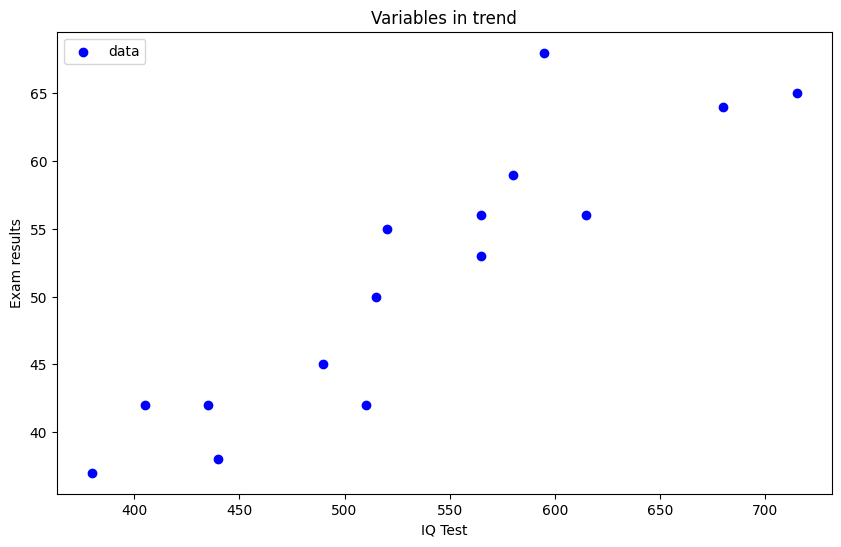

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(IQ_Test, Exam_results, c='b', label='data')
plt.xlabel("IQ Test")
plt.ylabel("Exam results")
plt.title('Variables in trend')
plt.legend(loc='upper left')
plt.show()

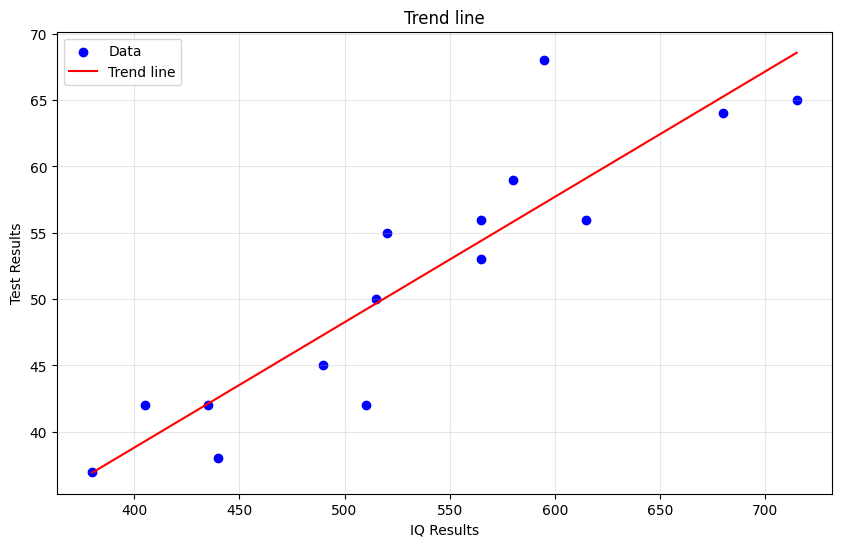

In [6]:


x = IQ_Test
y = Exam_results
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Data')

plt.plot(sorted(x), p(sorted(x)), color='red', label='Trend line')

plt.title('Trend line')
plt.xlabel('IQ Results')
plt.ylabel('Test Results')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.show()

 The charts above shows that variables "x", and "y" clearly described uptrend direction.
 The directional joint move of two variables is mesured by COVARIANCE of "x" and "y", or cov(x, y).

$\bar{x}$ - Arithmetic mean

$\bar{x} = \frac{1}{n}\sum_{x=1}^{n} x_i$

$cov(x, y) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$

- When both variables increase - the covariance is positive
- When one variable increases and the other decreases - the covariance is negative
- If both variables do not vary - the covariance is zero "0".

In [7]:
# Covariance of IQ test and Exam results #

In [8]:
np.cov(IQ_Test, Exam_results)

array([[9318.57142857,  880.85714286],
       [ 880.85714286,  102.12380952]])

In [42]:
covariance_IQ_Exam = np.cov(IQ_Test, Exam_results)

Standard deviation:
- the differences between $x_i$ and $\bar{x}$ , $(x_i - \bar{x})$ is positive or negative, their sum is up to "0"

- when we square them (all positive) - $S^2(x) = \frac{1}{n-1}\sum_{x=1}^{n}(x_i - \bar{x})^2$

- Standard deviation - $S(x) = \sqrt{S^2(x)}$

$p_i = \frac{(x_i - \bar{x})}{S_x} \frac{(y_i - \bar{y})}{S_y}$, divided by standard deviations, we "normalize" them.

$p = \frac{1}{n}\sum{p_i} = \frac{cov(x, y)}{S_xS_y}$
-"p" - Pearson correlation coefficient

In [10]:
stdev_IQ_test = st.stdev(IQ_Test)
stdev_Exam_results = st.stdev(Exam_results)

In [11]:
stdev_IQ_test

96.53274795928803

In [12]:
stdev_Exam_results

10.105632564258881

In [13]:
#Let's continue with our example and put two variables list in matrix

In [14]:
matrix = [x, y]

In [15]:
#Transposition of matrix .

In [16]:
transposed_matrix = [list(row) for row in zip(*matrix)]

In [17]:
labels=["IQ Test", "Exam Results"]
pd.DataFrame(transposed_matrix, columns=labels)

,IQ Test,Exam Results
0,595,68
1,520,55
2,715,65
3,405,42
4,680,64
5,490,45
6,565,56
7,580,59
8,615,56
9,435,42


In [18]:
P_IQ_Exam = covariance_IQ_Exam/  (stdev_IQ_test * stdev_Exam_results)

In [19]:
P_IQ_Exam

array([[9.55237066, 0.9029575 ],
       [0.9029575 , 0.10468606]])

In [20]:
st.correlation(IQ_Test, Exam_results)

0.9029574959390204

In [21]:
np.corrcoef(IQ_Test, Exam_results)


array([[1.       , 0.9029575],
       [0.9029575, 1.       ]])

In [51]:
print(f"Pearson coefficient of correlation is : {np.corrcoef(IQ_Test, Exam_results)[0][1]:.4f}, positive and strong (close to 1) ")

Pearson coefficient of correlation is : 0.9030, positive and strong (close to 1) 


In [22]:
# Function for multiple usage with different data for two variables, and  visualization

In [68]:
def Data_frame(var_1:list,var_2:list):
    array = [var_1, list(var_2)]
    transposd_array = [list(row) for row in zip(*array)]
    labels = [ input("Enter lable"), input("Enter lable") ]
    df = pd.DataFrame(transposd_array, columns=labels)
    return df

def Pearson_correlation(var_1:list,var_2:list):
    return st.correlation(var_1, var_2)

def plot_correlated_variables(var_1:list,var_2:list):
    x = var_1
    y = var_2
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='purple', label='Data')
    plt.plot(sorted(x), p(sorted(x)), color='blue', label='Trend line')
    plt.title('Pearson Correlation with a trend line')
    plt.xlabel('IQ Results')
    plt.ylabel('Exam Results')
    plt.grid(True, alpha=0.5)
    plt.legend(loc='upper left')
    return plt.show()





In [34]:
Data_frame(IQ_Test, Exam_results)

,IQ Test,Exam Results
0,595,68
1,520,55
2,715,65
3,405,42
4,680,64
5,490,45
6,565,56
7,580,59
8,615,56
9,435,42


In [35]:
Pearson_correlation(IQ_Test, Exam_results)

0.9029574959390204

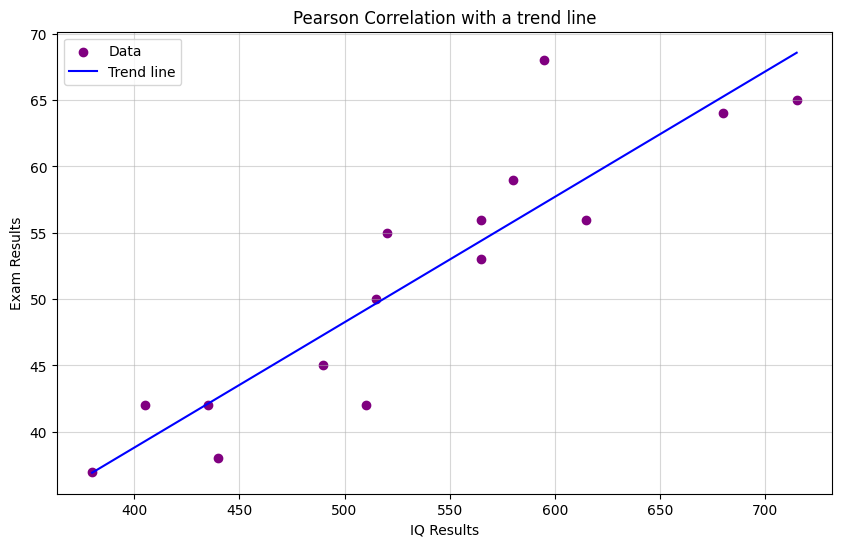

In [37]:
plot_correlated_variables(IQ_Test, Exam_results)

  PART 2: SIMPLE LINEAR REGRESSION

The Concept: From Association to Prediction
While correlation tells us how much
 and
 move together, Regression allows us to predict
 (the dependent variable) based on
 (the independent variable).
We are looking for the equation of the "Best Fit" line:

$Y = \beta_0 + \beta_1X + \varepsilon$
- $\beta_1$ (slope) - How much form previous example Exam Results increases for evry one point of IQ Test increase.
- $\beta_0$ (intercept) - The predicted value of Exam Results, if IQ Test were "0"
- $\varepsilon$ - stochastic part of the model

To find the line that minimizes the distance between the data points and the line (Ordinary Least Squares), we calculate:

Slope:
- $\beta_1 = \frac{cov(x, y}{var(x)}$

Intercept:
- $\beta_0 = \bar{Y} - \beta_1\bar{X}$

In [ ]:
# Calculating means of both IQ_Test and Exam_Results
mean_iq = np.mean(IQ_Test)
mean_exam = np.mean(Exam_results)

In [46]:

# Calculating b1 (slope)
# Using [0,1] from  covariation matrix and variation of X
var_iq = np.var(IQ_Test, ddof=1)
#cov_iq_exam = np.cov(IQ_Test, Exam_results)[0, 1], we already defined it as covariance_IQ_Exam = np.cov(IQ_Test, Exam_results) form previous example
covariance_IQ_Exam = covariance_IQ_Exam[0, 1]

b1 = covariance_IQ_Exam / var_iq
b0 = mean_exam - (b1 * mean_iq)

print(f"Coefficient b1 (Slope): {b1:.4f}")
print(f"Coefficient b0 (Intercept): {b0:.4f}")

Coefficient b1 (Slope): 0.0945
Coefficient b0 (Intercept): 0.9892


In [62]:
print(st.linear_regression(IQ_Test, Exam_results))

LinearRegression(slope=0.09452705810210026, intercept=0.9892176401451351)


Estimation of the model:
- 1. Mean Squared Error (MSE): If value of MSE is lower, that means the model works good

     MSE = $\frac{1}{n}\sum(Y_{actual} - Y_{predicted})^2$

- 2. $R^2$ Coefficient of determination: $R^2$ is measure of the goodness of fit of model. In regression $R^2$ measures how well the predictions approximate the real data points. An $R^2$ of 1 indicates that the regression prediction perfectly fit the data. If $R^2$ is outside the range of [0, 1], the model fits worse the data. For simple linear regression with only one predictor , $R^2$ equals the square of the Pearson correlation coefficient:

In [53]:
# Generating predictive values (Predictions)
predictions = [b0 + b1 * x for x in IQ_Test]

# Calculating the errors (Residuals)
residuals = np.array(Exam_results) - np.array(predictions)

# 1. MSE
mse = np.mean(residuals**2)

# 2. R-squared
r_sq = st.correlation(IQ_Test, Exam_results)**2

print(f"MSE: {mse:.2f}")
print(f"R^2: {r_sq:.2f}")

MSE: 17.60
R^2: 0.82


For better interpretation can use RMSE: RMSE = $\sqrt{MSE}$, or RMSE = $\sqrt{17.60}$ $\approx{4.20}$, or on average the model's predictions differ from the actual values by around 4.2 units

In [60]:
RMSE = sqrt(mse)

In [61]:
RMSE

4.195439212750221

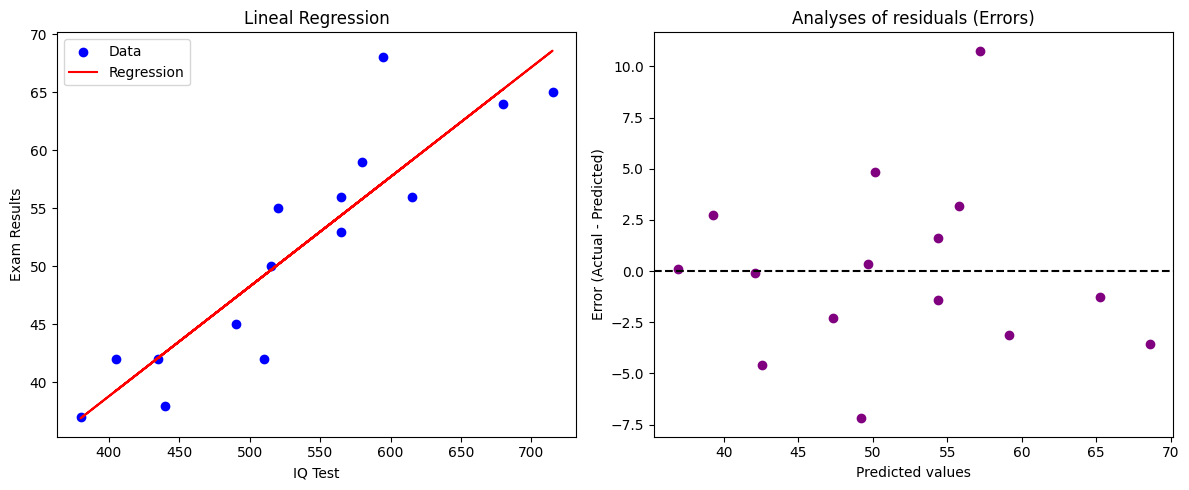

In [56]:
def plot_regression_summary(x, y, preds):
    plt.figure(figsize=(12, 5))

    # Plot 1: Regression line
    plt.subplot(1, 2, 1)
    plt.scatter(x, y, color='blue', label='Data')
    plt.plot(x, preds, color='red', label='Regression')
    plt.title("Lineal Regression")
    plt.xlabel("IQ Test")
    plt.ylabel("Exam Results")
    plt.legend()

    # Plot 2: Residuals
    plt.subplot(1, 2, 2)
    plt.scatter(preds, residuals, color='purple')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.title("Analyses of residuals (Errors)")
    plt.xlabel("Predicted values")
    plt.ylabel("Error (Actual - Predicted)")

    plt.tight_layout()
    return plt.show()

plot_regression_summary(IQ_Test, Exam_results, predictions)

As we already calculated $R^2$ = 0.82, that means 82% of the variability in Y(Exam Resuls) is explained by the model, while 18% remains unexplained, so MSE = 17.6 . As plot 2 shows the residuals looks randomly distributed arround "0". Overall indicating the model assumptions ara reasonably satisfied. The regressin model provides a good fit to the data, explaining a large portion of the variability, while maintaining relatively small prediction errors.

Next step is to continue with the example by using the model to make forecast about new studens.This the real value of Linear regression - based on analises of the past to predict the future.

In [63]:
# Using the calculated b0 and b1

def predict_exam_score(iq_value):
    score = b0 + (b1 * iq_value)
    return score

# Example: Expected exam result of student with IQ = 600?
new_iq = 600
predicted_result = predict_exam_score(new_iq)

print(f"For IQ = {new_iq}, Model predicts exam result: {predicted_result:.2f}")


For IQ = 600, Model predicts exam result: 57.71


Assume, there are 3 new students with different IQ levels. Let's see their expected (predicted) exam results.

In [64]:
#Add values for the new students
new_students_iq = [450, 550, 650]
predictions = [predict_exam_score(iq) for iq in new_students_iq]


In [65]:
predictions

[np.float64(43.52639378609025),
 np.float64(52.97909959630027),
 np.float64(62.4318054065103)]

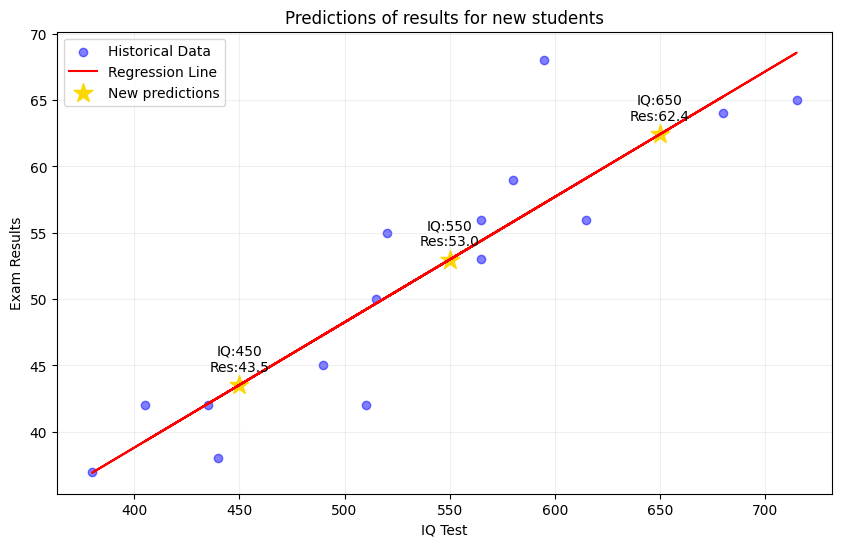

In [67]:
#Visoalization
plt.figure(figsize=(10, 6))
plt.scatter(IQ_Test, Exam_results, color='blue', alpha=0.5, label='Historical Data')
plt.plot(IQ_Test, [b0 + b1 * x for x in IQ_Test], color='red', label='Regression Line')

# Marking predicted values by "*"
plt.scatter(new_students_iq, predictions, color='gold', marker='*', s=200, label='New predictions')

for i, iq in enumerate(new_students_iq):
    plt.annotate(f"IQ:{iq}\nRes:{predictions[i]:.1f}", (iq, predictions[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title("Predictions of results for new students")
plt.xlabel("IQ Test")
plt.ylabel("Exam Results")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


CONCLUSION:

In this article was traced the path from Pearson Correlation to Lineal Regression. The given example was sa simple as possible, because the goal was to reveal the fundamental meaning of both tools. There are many more  regression and correlations models , but their explanation is beyond the current discussion.




SUMMARY:

- Pearson correlation ($r\approx{90}$) represents strong proportional relationship between IQ and Exam results.

- Lineal Regression gave us a formula , so that we cen predict future score with relatively good extent of accuracy ($R^2\approx{82}$)

In [69]:
#Sourses:
# - Крассимир Калинов - Статистически методи в поведенческите и социалните науки
# - Соня Чипева, Венелин Бошнаков - Въведение в иконометриятя
# - AI about advanced plotting (Matplotlib)
# - Wikipedia - Linear Regression